In [ ]:
# -----------------------------
# ResNeXt50 baseline for WaDaBa
# Frozen pretrained backbone, train fc classifier head only
# NOW USING STANDARDIZED DATA
# -----------------------------

import os
import copy
import time
import shutil
import getpass
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset

from torchvision import transforms
from torchvision.models import resnext50_32x4d, ResNeXt50_32X4D_Weights
from google.colab import drive

from tqdm import tqdm

# -----------------------------
# 0. Mount drive and define paths
# -----------------------------
drive.mount('/content/drive')

# Folder in MyDrive containing the ZIP files
PATH_OF_DATA = '/content/drive/MyDrive/Deep Learning Project/Wadaba Dataset/'

# Local SSD folder in Colab for extracted images
local_path = '/content/wadaba_local'

# -----------------------------
# 1. Sanity checks
# -----------------------------
assert os.path.isdir(PATH_OF_DATA), f"Drive folder not found: {PATH_OF_DATA}"

zip_files = [f for f in os.listdir(PATH_OF_DATA) if f.lower().endswith('.zip')]
assert len(zip_files) > 0, f"No zip files found in {PATH_OF_DATA}"

print(f"Found {len(zip_files)} zip file(s) in Drive folder.")

# -----------------------------
# 2. Extract images to local SSD if needed
# -----------------------------
if os.path.isdir(local_path):
    extracted_images = [
        f for f in os.listdir(local_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
else:
    extracted_images = []

if len(extracted_images) > 100:
    print(f"Images already extracted in local SSD: {len(extracted_images)} files. Skipping unzip.")
else:
    print("Extracting images to local SSD...")
    os.makedirs(local_path, exist_ok=True)

    pwd = getpass.getpass('Enter WaDaBa Zip Password: ')

    # unzip all zip files from Drive folder into local SSD
    !cd "{PATH_OF_DATA}" && unzip -P "{pwd}" -qo "*.zip" -d "{local_path}"

    # flatten subfolders
    print("Flattening subfolders...")
    for root, dirs, files in os.walk(local_path):
        if root == local_path:
            continue
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                src = os.path.join(root, file)
                dst = os.path.join(local_path, file)
                if not os.path.exists(dst):
                    shutil.move(src, dst)

    # remove remaining folders
    for item in os.listdir(local_path):
        item_path = os.path.join(local_path, item)
        if os.path.isdir(item_path):
            shutil.rmtree(item_path)

    extracted_images = [
        f for f in os.listdir(local_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    print(f"Done. Extracted {len(extracted_images)} image(s).")

assert len(extracted_images) > 0, f"No extracted images found in {local_path}"

# -----------------------------
# 3. Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# 4. Dataset class
# -----------------------------
class WadabaData(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.image_files = sorted([
            f for f in os.listdir(root_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])

        self.label_map = {
            'a00': 0,  # missing or unreadable
            'a01': 1,  # PET
            'a02': 2,  # PE-HD
            'a03': 3,  # PVC
            'a04': 4,  # PE-LD
            'a05': 5,  # PP
            'a06': 6,  # PS
            'a07': 7   # other
        }

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.root_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        label = 0
        for code, idx_val in self.label_map.items():
            if code in img_name:
                label = idx_val
                break

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)


Mounted at /content/drive
Found 20 zip file(s) in Drive folder.
Extracting images to local SSD...
Enter WaDaBa Zip Password: ··········

20 archives were successfully processed.
Flattening subfolders...
Done. Extracted 4000 image(s).
Using device: cuda


In [ ]:
#INDEX VALUES FOR TRAINING/VALIDATION/TESTING DATA PARTITION <-- COPIED DIRECTLY FROM BEN'S

trainingSet = [639,3402,441,464,3153,1889,3005,3145,3512,2396,2831,2957,703,76,2724,1284,2440,1469,1698,3258,850,3251,3922,1507,1310,728,785,393,3915,1927,3963,1000,592,3192,912,3572,2322,1959,545,2913,2830,2473,3435,1869,479,1331,2151,3761,3352,2923,482,2436,1285,3269,602,1629,267,2916,3677,3540,2734,1595,3062,3434,3391,3674,245,1920,811,489,2805,3573,2372,3021,2576,2635,1738,2333,600,3381,2034,2412,685,1009,228,1555,2299,2355,2713,768,2350,3863,1416,1861,449,2579,755,810,1767,3386,765,3079,1583,1512,1845,3084,2943,2925,1630,2019,238,54,295,2217,1997,3531,3740,3171,1955,621,1119,996,1727,2668,2868,3729,2835,2975,1219,2860,1936,911,926,1556,935,708,3669,1919,2417,2760,3585,2678,1005,3072,2196,3482,3172,3928,1424,2749,93,3230,578,1405,1138,746,70,3100,2076,2212,2526,3051,395,861,1766,335,217,3170,1776,2846,512,1562,1863,3013,1879,2279,3431,1077,1216,213,1028,2470,2876,1086,3983,2320,3617,1128,2475,3314,2105,1239,7,2658,3270,2006,340,668,903,2574,3456,908,236,3350,3567,2870,2203,241,3935,1996,136,2216,2822,3473,30,2136,3651,665,1066,188,1217,1740,3288,3698,3460,1493,2384,2798,2100,3769,622,1497,331,3092,252,1223,989,2492,528,1342,3713,3805,923,301,716,3971,2059,1398,781,2767,47,2088,2044,3283,3163,1948,1816,1520,1472,3004,3604,484,3131,673,1330,505,1785,2101,2792,723,2147,552,2247,1286,3977,3996,3796,2834,106,1038,2164,400,3696,1686,3727,3613,2675,3343,927,1298,3931,1795,1901,2143,2990,3210,771,428,775,1151,299,3162,2013,804,3117,1664,1272,2385,184,2341,1247,309,2937,2626,1311,2399,1754,1249,953,3095,152,2843,3126,1940,1394,2392,3144,2077,2338,916,2380,677,868,407,40,1723,2976,3666,1407,3124,992,1899,3592,1968,828,3115,1387,1052,3787,3447,3788,1265,1942,366,2319,1883,879,205,2446,3866,3764,3202,1015,3872,459,2795,2052,2266,79,1518,2329,1374,1736,2924,2131,2110,2823,753,326,3979,3070,635,291,3365,1995,2158,1800,3656,1705,1724,2912,3818,1728,6,3492,3947,930,1978,1231,1150,3562,1167,3,490,3542,847,444,1864,2306,1414,1684,2309,1718,1756,3304,247,1749,1476,691,1019,1292,1379,1657,314,2774,3479,937,42,1847,2942,2932,33,1409,2972,575,1317,1646,931,807,1308,1026,2413,2995,1819,1655,1582,2518,3786,2323,2933,3910,374,624,3007,1865,3588,533,3827,202,12,1141,2114,24,1558,1974,356,3059,3025,381,1032,577,2437,1093,3799,3837,2813,2340,406,3829,3349,1040,1762,2345,2029,3768,3307,2390,3639,2777,2698,1575,3268,1612,2740,2608,1305,836,1550,742,2558,520,266,2549,3808,878,1260,2585,1887,3804,3377,629,3312,3066,2317,2704,909,1696,3760,1419,3826,1105,3616,1111,1483,3864,1654,2119,2679,3882,3773,1637,1932,3029,2855,2572,517,620,3459,2894,2455,3793,3543,1123,1811,1638,547,1649,3240,1056,1585,1168,870,3621,2667,1303,347,3965,610,2227,3675,1642,3436,646,3086,420,318,1672,3519,1025,532,1508,3568,3896,1306,2425,1316,3211,2996,1805,421,3338,1114,1341,3274,3440,3806,1506,2408,2415,5,1529,2162,2866,1946,2874,375,566,3179,289,2284,2047,1513,2480,2684,2352,1708,2955,1852,943,264,783,1868,1521,3660,1203,3576,3581,3243,1014,1044,2858,358,779,191,3986,3470,85,1639,3705,447,3106,2985,687,2270,2627,3488,1422,1172,344,3507,683,2790,244,3112,2826,766,1069,3825,559,3322,3535,1062,1841,2234,1924,581,3984,1275,2252,1610,2671,2773,802,777,316,3398,2696,1498,1533,2477,2721,3694,1224,3096,379,803,3746,745,1189,3502,2428,1380,1522,1644,922,3640,2014,919,3328,940,522,1568,3516,3918,1747,1794,1802,3927,2939,1234,2997,1085,1479,2902,1244,271,3372,53,1163,1799,204,3462,1591,2434,1803,328,150,1586,2890,1893,499,3257,3700,2983,1434,3504,1515,1071,1786,3730,3597,2828,1701,28,3987,2872,1177,2612,3952,749,3668,698,2318,317,1384,3168,2045,3132,1338,899,2532,2714,3395,2573,2083,2195,159,540,1145,3347,370,2662,3393,1323,2837,1856,1411,2657,2581,1475,1087,86,2739,2695,345,1103,3335,3130,2419,1998,717,13,2000,408,2672,1471,1634,1131,2945,359,1618,95,2098,587,573,3861,3489,3109,3913,3474,1420,1973,2327,1307,1257,3881,1807,1725,2454,1083,197,2126,2107,2003,1721,696,510,219,310,738,2022,2647,1922,1124,588,1501,3380,3738,1294,1023,1752,31,2641,1053,721,1632,1653,980,1679,2242,714,1532,2879,133,37,2548,1299,2063,1282,571,2541,167,3344,655,1538,1064,2793,3263,1711,3387,3949,196,3030,2687,1430,170,123,3618,3612,2648,1592,3259,1152,672,675,1935,963,3156,477,3000,3122,3407,2600,58,2288,3451,413,661,1371,3342,258,0,2738,611,3510,3615,417,3478,3560,1241,561,2791,891,3102,180,2705,3158,2880,3298,3697,3834,526,498,2490,585,2463,2344,1372,2737,2021,2231,3190,3946,615,3204,388,2062,1761,3242,3385,580,2122,200,336,1089,2781,1748,2192,108,3362,3229,3695,1830,3556,1788,3565,3701,2515,3330,1207,3670,1884,1418,1505,492,538,1340,2556,1790,260,3775,3982,3879,3812,3281,1733,3421,3902,938,3034,3024,560,3284,3311,456,97,2418,2185,967,1185,496,1215,671,3956,269,3645,1541,1060,3091,939,3384,1855,3483,976,1793,2993,3846,1871,3101,3999,2589,3250,199,2636,3948,3570,654,1880,3643,2941,88,2313,1941,3280,1227,1771,1369,3241,1910,160,1500,14,3040,3185,2377,1180,3418,1673,113,263,1784,300,2982,2241,3797,2221,3374,320,3399,195,3071,3525,2620,2429,2452,1993,2958,1262,772,3303,1441,2583,950,3974,3262,1491,3184,1906,1448,1110,1943,2432,1435,129,3895,609,1070,1702,2179,1614,21,1157,3649,218,419,3657,1302,973,2001,3410,993,1002,2259,1456,1801,2459,3035,2611,1977,2661,1735,2451,1900,1181,2569,3265,2193,3119,2801,543,2305,2189,3925,410,3924,1781,3082,3287,72,3104,2245,3582,705,2652,2501,2666,59,3186,3814,1986,914,2884,2402,761,2130,2735,84,2008,3860,2159,2677,3267,2172,327,3653,1365,2586,905,1921,1626,3791,2533,730,3406,1403,541,282,80,763,3871,3810,71,699,1033,3247,3176,1839,132,667,1989,3981,2546,2009,2670,3772,1347,3528,3541,3049,1304,2959,2171,3001,3465,3703,476,2378,565,1671,1139,1154,2645,637,3970,2604,3292,3886,1288,182,1423,2743,2260,3196,1903,2951,3367,1624,1,493,606,2081,1375,3403,1982,1848,727,841,325,2199,2977,380,1197,1546,1473,1720,790,3404,1683,568,224,2934,1174,3901,2806,1029,3012,1658,243,3437,2517,824,298,2748,627,3619,883,1442,2918,1984,2984,458,3143,2808,220,2325,893,3422,1107,617,2042,881,1133,1905,2903,3690,2686,2141,3045,1827,2035,704,1622,3742,1043,1716,46,3752,2851,1815,1382,2400,431,3506,954,287,148,2909,1504,1873,2483,262,465,2157,614,1579,183,3533,1354,226,103,2543,955,2075,2373,3009,2115,1970,952,2820,3426,551,970,3865,1760,190,3595,3847,2690,2799,77,3332,968,2381,43,198,759,2397,1240,3583,357,369,3559,1652,3785,2360,3253,44,1588,1328,958,1259,3628,2886,2489,210,1175,1693,2161,3023,3877,3264,2239,1628,2409,1449,1450,2301,1485,480,2730,642,3884,808,3054,3438,3676,1963,640,2986,3252,3873,1367,3782,1439,1670,2794,3317,702,2435,660,3759,1834,454,1904,3911,1129,3816,2853,472,1489,1822,1279,3382,2481,1315,1818,1274,3822,888,2850,2733,1179,3157,2342,3754,3226,1917,3942,349,2255,2561,791,2940,1931,695,50,2180,2308,3998,830,3587,2631,1866,3239,2591,3140,3817,1334,2825,567,2888,898,3755,206,1806,81,143,371,1527,3887,435,1135,3073,383,2936,1205,3178,593,3839,760,2218,3193,2547,643,3840,2146,1779,2456,2493,1798,1137,2973,1722,2294,1042,3108,2423,3832,2854,265,1401,3301,641,2315,2507,546,1336,2121,634,2812,2829,1557,3003,1726,1046,3441,272,1844,942,1944,1118,1826,3709,1134,3058,1772,297,2601,153,3466,638,1386,1526,172,1264,1470,1225,1503,3890,2271,1368,2285,1352,2283,2683,2394,257,569,1160,1813,2596,2258,1058,2864,2689,229,3351,3136,3476,1041,27,3455,253,1003,941,3424,1467,2577,3652,2575,1810,3735,1953,3584,3685,1913,2085,2361,1601,3611,1198,2509,3527,1577,767,101,2207,20,2503,2885,2324,2804,2038,857,427,3138,2233,3750,3711,1433,713,2471,508,2981,2660,1487,1037,2699,653,2092,2111,890,2148,2176,2020,1576,1862,1320,48,3026,2229,2025,2028,2867,2905,3511,678,1734,3088,3577,1267,2343,65,3249,321,1243,500,3203,3094,1656,1689,3481,2166,2334,1886,3093,312,662,633,2637,1553,2335,3995,3593,2922,342,2513,1994,446,3369,2314,3880,3491,2994,2710,3392,1061,2646,957,2109,3606,1674,2535,910,3868,1022,3321,2430,3368,376,1277,2036,127,3815,3545,140,2238,2358,3496,1688,801,270,3486,2961,762,1593,3340,863,956,3586,1444,2883,3485,756,2935,3041,718,392,2552,1392,867,1295,2788,2802,49,1359,535,3934,2103,2523,3631,3941,3693,1059,2703,2303,2183,1291,3390,2316,426,3579,3897,3702,164,3850,3366,433,618,3234,805,3309,1846,3758,2920,437,2616,945,1950,1233,1335,1969,3899,3195,623,1445,837,3849,2152,2370,2746,648,1661,161,1991,2307,3152,3346,2992,1012,2433,3430,1031,647,467,3205,1050,240,2815,1870,3279,2970,3361,2261,1561,1132,115,360,2557,404,333,1361,2727,3020,2055,3780,3121,2665,886,674,2643,1220,3414,1918,3159,3774,1651,562,1024,3800,3468,2280,3637,2297,1495,594,1992,1068,2030,2504,75,986,3932,2080,530,3042,2989,2002,1236,2952,3990,3439,2244,865,363,871,73,3536,1833,2486,657,1837,3469,2551,1792,2458,2718,2113,1825,3063,1840,2614,390,550,3334,784,2633,259,2776,1509,39,2072,1200,754,2610,1477,1268,1633,3299,3546,1159,1186,2833,3875,362,3500,1242,1894,1742,1187,3686,3844,1144,3475,1933,1552,2723,3724,3664,1572,3415,3513,2353,2354,146,3197,815,3722,1804,1296,1389,900,907,583,3305,1519,3969,3636,2891,1613,398,2688,147,98,3089,2250,2818,1146,3566,3008,2609,1542,3277,2154,2086,2478,2598,227,2379,255,1202,1399,1645,3261,1212,3161,3518,2836,1451,821,3167,1313,429,1755,3166,2862,2118,1091,3326,1324,8,2240,3823,1554,2702,2491,4,3852,3174,177,3708,124,2527,1158,2832,818,656,368,3997,1712,2930,729,311,866,194,556,887,1965,1669,2194,3591,1744,2761,2722,3654,3068,2024,736,1530,1094,663,948,1232,2910,62,2215,3458,1102,2584,2445,1263,290,3771,2251,3497,3689,145,2018,1344,3602,3206,2906,1570,3120,934,2560,1017,764,2810,1912,1773,3721,1289,2139,3155,329,1525,2439,1821,558,2362,1907,3517,1764,3014,1952,3081,112,1777,2848,1643,2800,1930,2051,1812,988,174,411,2562,2057,279,1667,601,2599,1594,137,2137,3820,2944,3912,384,409,1925,2931,1979,2536,285,1321,3930,3766,812,666,680,1117,2499,1600,834,2068,1717,216,1104,840,3544,2901,3050,2555,1195,856,3467,2717,497,3147,3397,769,2232,2404,3638,3603,2295,1436,1273,2803,2578,2007,2844,3275,1987,650,1048,1097,3551,1961,2466,2079,1911,3888,1391,2887,2673,997,2784,3037,3994,1076,949,2619,1206,1067,3359,959,2824,278,453,2538,2949,1898,990,2174,23,1809,1565,2921,2184,3148,1345,3988,851,2278,820,2383,3992,2966,3779,3110,2177,1036,1377,3958,256,469,2349,902,1975,504,3614,3069,1564,1697,2511,1876,1329,1548,3010,2089,2363,1095,3725,3765,947,1981,896,1789,2336,2186,3214,1281,3057,814,3590,1080,451,474,1951,1823,882,906,405,1663,3828,3031,1571,1115,544,3954,2296,221,707,2842,1891,1641,149,452,2628,2960,1246,3870,3859,3940,3471,2403,354,3038,733,3046,1063,1011,3289,2745,2041,724,1964,3378,3561,1949,313,2979,3208,2697,3113,1709,341,3973,2293,3699,1337,3783,1947,1536,2395,2617,3463,1404,2763,554,3682,596,2187,353,2751,1872,2674,3530,3276,616,1598,2911,1559,595,2012,3296,747,254,603,1606,2031,3550,1703,3160,590,3571,3151,689,884,773,983,1327,1681,2011,1763,743,485,625,2442,3348,2387,57,3333,3671,645,3266,3707,1758,176,1937,1621,1665,2653,692,1421,2857,130,854,1843,3083,334,3926,1619,1121,845,3663,3207,3019,2917,3547,2819,430,3635,3748,2991,776,1574,3960,1620,2290,3227,502,1360,3706,2153,1213,481,1221,2237,233,418,2998,3294,2720,142,1013,3354,572,1393,1468,2758,1090,1625,3285,2963,3223,3601,3962,2120,1808,3216,2893,1300,2116,1787,3842,2642,979,2204,304,3807,3522,223,1108,403,382,303,2465,373,631,1373,386,3080,2554,1838,2219,1604,3495,119,494,514,3423,2892,795,3255,51,3449,734,744,168,378,3135,3272,3529,737,1065,3523,125,2168,2838,2962,3047,832,2167,185,3532,2367,534,1410,1376,1976,2027,920,2078,2692,701,690,2592,116,3097,3016,1252,2709,529,2980,1438,3514,3244,518,1125,3661,3053,60,461,2274,296,122,3286,3972,780,3599,276,3076,3790,2140,158,488,1611,214,1851,2182,1166,3841,207,3833,2209,1780,2091,3920,1248,286,1357,3598,232,2426,2056,2102,788,521,752,2198,364,858,322,1659,2525,1547,389,3290,3355,1169,3622,2845,3747,2759,1858,2602,542,2040,2246,118,1854,2878,2615,377,3762,2651,978,825,3428,2978,3036,307,1461,1147,1514,3732,277,3236,2719,2655,2474,1714,1183,2908,2625,2422,1325,855,1877,524,2756,3379,3215,2974,2476,1607,1596,527,3341,3306,608,3989,66,2498,999,1732,838,918,670,3219,19,2732,586,1283,2849,3610,3336,2680,1245,1397,3665,3419,2967,984,2282,2814,251,3017,1100,1647,921,1853,2438,2304,440,3909,67,874,2816,1895,2772,2037,1192,2073,3055,131,1835,2787,3878,3662,2947,323,3626,2188,726,2544,1902,2230,3991,3137,3719,1695,3625,3856,1396,682,275,1782,3248,2457,3237,63,89,2134,3624,486,1332,1001,2262,3803,100,591,2796,711,2023,789,187,1278,3505,2603,1112,2026,2588,3394,248,735,2768,2956,3425,2356,3319,32,2904,2506,3141,793,3271,2346,2094,68,34,2841,2807,2243,3961,3420,1650,644,3623,3939,1440,3400,1753,1878,1569,1214,658,3933,3501,3728,2496,722,1934,1945,2276,3429,2953,1710,3245,2222,3838,880,3726,3739,835,1687,2564,2065,3794,3150,823,3609,3356,799,626,2135,3836,308,274,2664,1757,826,1490,2590,2753,964,1156,1126,3811,3313,531,3976,74,969,2685,3364,1578,1707,3633,1603,280,1190,3845,3900,794,3893,3632,1370,564,2375,3830,3228,1494,1699,2786,3043,961,361,3679,1926,1193,1549,2605,169,3558,846,3795,2754,442,712,2286,1269,684,3629,339,2348,2211,1165,2263,1849,1867,2809,1092,2694,605,3499,3869,284,2328,29,1985,853,3763,1660,669,2129,965,1081,676,2516,2287,173,3212,35,2797,3177,1706,438,231,2213,2128,3293,2747,2257,3894,1191,3745,201,748,2606,3189,3608,2366,2236,901,128,3443,3549,1176,1590,1682,862,1543,2292,1312,1184,3188,3667,2587,3835,3980,1457,337,2127,3098,2877,2926,387,3575,933,848,598,859,3929,211,2550,3175,2706,2427,3753,2640,852,2964,1567,757,9,3672,3217,156,3323,2138,3641,288,2999,2407,3331,917,3324,2447,3114,281,1072,1276,1453,2701,2201,1881,844,121,2411,816,181,372,1173,3889,3327,3824,2441,2256,203,3691,1417,1004,1938,1261,2514,1478,3943,932,3056,1745,3316,2865,2124,2895,1073,3493,995,1857,3320,2708,3358,864,273,2607,1737,3539,3417,293,56,3200,401,1385,3509,897,1057,2968,3955,2613,3133,2479,2273,1563,1162,1954,3898,974,2582,2420,242,1627,2269,3574,2779,2268,3061,3916,925,1775,324,1523,2374,38,1464,3044,1427,1675,2487,3684,283,415,3028,3260,3039,2048,87,2622,1178,1939,1892,423,315,2264,2267,162,1635,2593,3650,1127,424,385,82,1914,1499,1021,3412,3813,3222,3534,2410,2540,1482,2863,2580,3232,3450,829,2716,985,827,1715,2351,1355,758,975,1229,2443,3409,1099,1531,3892,2712,3874,1412,519,1875,694,2852,709,2032,3798,3225,833,1196,1832,3209,2444,1587,2929,1164,365,3221,306,261,3734,2782,688,1388,1079,3411,3985,2265,1746,782,45,1255,2097,1142,396,2391,3278,1666,2016,3524,2669,3630,397,3149,3048,246,2731,83,436,3125,2725,982,1293,706,2311,2386,2715,1322,1797,2624,849,3181,343,2060,3448,1890,872,2398,3821,3315,3452,936,2178,819,1511,2064,944,3408,2928,875,3022,1958,237,3067,2766,1831,523,2542,235,249,3503,2,2046,2736,2896,2117,2530,2881,3831,3329,2382,536,2630,557,1481,1209,3687,1741,2155,3642,1662,1297,1544,1528,16,1194,268,3905,659,582,3256,2401,105,3731,3337,1962,3194,120,2676,3461,2623,2521,1390,1488,2634,613,1636,468,483,1049,1237,3917,3508,3011,3224,3401,3673,155,778,412,1458,3964,2570,457,501,3951,2566,636,1446,1516,628,2010,3776,2061,537,2431,2869,2500,3715,111,3944,2898,3855,1617,962,2310,1120,1096,64,998,2553,2563,3809,740,2448,809,2450,2946,732,1130,2597,3154,175,2326,171,3569,2520,215,2621,1432,792,1916,2321,11,2359,10,1908,3032,2859,1648,138,1431,2074,3388,2528,2277,2416,2495,2142,509,563,2084,515,193,2839,2650,3914,1136,806,1685,3246]

validationSet = [1226,18,351,885,434,2531,487,3318,3736,2488,3883,570,3446,1677,3891,913,2594,892,3370,3134,3718,1882,3297,607,3105,2058,3128,2200,3515,2729,1271,2537,1035,2595,3396,1101,2567,3302,3714,2170,2914,3173,1750,104,2254,1765,1616,144,1148,367,2508,445,1704,2347,2744,725,3716,651,1486,17,1253,3183,3737,1314,652,3756,2919,1395,3620,1560,1885,1605,1356,3300,915,1358,302,26,1836,3164,2093,2565,250,1535,2741,3254,2087,2954,1161,2160,3959,350,3538,1143,135,503,700,1088,507,1113,475,1999,2175,3060,2750,1615,1623,813,1238,1608,1413,2449,928,2691,2873,3678,1796,2015,3065,2897,3308,719,2123,1988,1381,2762,1350,151,2339,1251,107,166,3950,2371,109,1055,1694,3006,3548,2248,1140,2220,2365,1730,548,3432,432,3778,2472,3371,1874,3634,495,574,1462,889,2069,1820,817,189,842,2485,1078,3238,1510,2125,3688,1602,222,3139,192,1364,1474,3099,2948,1768,3526,2190,3444,3520,3854,141,3273,178,2332,3938,697,2165,1465,800,1378,3681,1319,3018,2424,3111,473,3375,319,3413]

testingSet = [3199,1537,2163,3966,786,110,1496,1729,3921,1201,3383,2004,1573,402,3363,3819,3052,3325,2181,2206,1929,3903,2755,3521,2494,1609,1691,1363,1211,3165,966,1153,416,1452,1222,555,1584,2780,619,1106,96,3770,960,681,1425,3858,2988,2145,1731,355,2907,2331,2302,513,2173,2453,3692,2144,3182,3027,2112,2950,3857,1778,36,1258,3123,3015,1400,1690,1402,186,1539,750,3885,3978,2728,52,2639,1517,2462,1676,2039,3749,2393,2225,3712,3064,3757,1010,230,3554,1454,3600,2300,1824,3720,2464,2249,352,895,3919,3655,2817,1692,3198,425,3472,1346,1713,2099,3967,2757,3389,1210,1580,3802,2771,3646,3644,3453,55,3777,589,1415,1208,584,2066,157,525,731,924,1074,2388,1960,1426,134,455,3781,2223,3710,414,2214,3235,3416,3627,99,1739,1020,2693,2133,126,2840,1888,3751,3704,946,3218,2090,1280,2202,2461,3457,553,225,2497,2971,94,1366,165,90,1326,2871,2644,3169,3658,2005,3142,604,3553,2656,1680,3127,2938,1759,2700,3767,2827,3993,1018,3557,3129,1353,466,1348,2568,1351,1007,1455,422,2681,3789,2226,460,450,471,1082,2082,3146,2104,1897,212,2106,1915,1008,41,1896,873,1957,1182,1054,1039,2882,3074,1428,3580,1850,1599,1045,3733,2987,1256,1188,1589,1016,3937,2357,2414,770,2281,1463,391,1540,1116,3680,3537,1466,3743,2711,797,78,2228,2764,2785,163,1075,1923,1829,3596,715,1362,2054,1027,2017,2502,1966,2529,1333,3498,3118,831,3907,3078,179,294,1631,3717,1484,3552,3936,3180,720,3201,2775,3953,305,2421,1383,1817,3851,2095,3433,2043,1983,3647,1581,822,1204,1218,774,679,1551,2205,2510,2534,462,2742,3445,2210,2369,1122,338,2289,1700,1318,977,1290,1199,1235,2406,539,991,3360,3607,632,1155,1842,209,1502,332,3339,1783,3792,22,3876,3291,2900,114,1084,2512,2096,3494,2169,3090,1524,1743,2275,1408,1597,3345,1534,904,2915,292,599,2469,860,2889,2632,1971,3087,2659,3563,3231,1751,3075,3484,2707,1545,3085,2376,1170,2156,1443,2811,1860,686,2539,1339,69,2071,154,1309,1030,664,3213,3233,739,2682,2726,3282,3945,987,2191,2150,511,2482,1814,2783,1406,1967,3683,2505,3741,1250,2769,1774,693,741,1301,443,796,470,1429,3723,787,3904,2235,2559,1640,3848,1668,549,2765,3908,2053,869,2033,92,1980,3605,2108,1149,3555,239,3490,1719,951,3867,1859,1343,3923,2253,576,2389,399,3405,3477,2067,2638,1990,2298,3353,25,2847,2899,2070,2330,2618,1909,3968,1266,2545,2927,1928,3376,3862,2132,3427,1047,3002,876,3191,1006,3295,1051,2224,2405,843,3564,117,1349,2654,234,2460,971,2649,91,3659,3578,2856,612,2467,491,2291,2969,139,2368,3442,348,506,1770,579,1492,1566,208,102,2364,3487,2875,877,2208,2821,3648,3107,2522,3480,972,2571,3853,3843,2770,2197,929,346,2752,478,1109,1460,3784,649,1171,3373,61,3357,1228,3310,3957,1828,1287,1769,1480,3187,839,2663,710,994,330,2778,798,516,1034,2337,2468,3589,3594,630,894,3116,597,2519,1230,2312,2049,3744,3033,2965,1447,1270,3220,3077,3454,463,439,2524,15,1098,2484,2272,1459,3464,1678,3906,394,981,3801,3103,448,1956,2629,3975,2789,2050,2861,1791,1254,1972,2149,1437,751]

len(trainingSet)

3200

In [ ]:
# -----------------------------
# 5. Weight-specific transforms
# -----------------------------
weights = ResNeXt50_32X4D_Weights.IMAGENET1K_V2
eval_transform = weights.transforms()

train_transform = transforms.Compose([
    transforms.Resize((232, 232)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# -----------------------------
# 6. Full dataset and split
# -----------------------------
full_dataset = WadabaData(local_path, transform=None)
print("Total images found:", len(full_dataset))

train_subset = Subset(full_dataset, trainingSet)
val_subset   = Subset(full_dataset, validationSet)
test_subset  = Subset(full_dataset, testingSet)


class WadabaSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        real_idx = self.subset.indices[idx]
        img_name = self.subset.dataset.image_files[real_idx]
        img_path = os.path.join(self.subset.dataset.root_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        label = 0
        for code, idx_val in self.subset.dataset.label_map.items():
            if code in img_name:
                label = idx_val
                break

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

train_dataset = WadabaSubset(train_subset, transform=train_transform)
val_dataset = WadabaSubset(val_subset, transform=eval_transform)
test_dataset  = WadabaSubset(test_subset, transform=eval_transform)

print("Train images:", len(train_dataset))
print("Val images:", len(val_dataset))
print("Test images:", len(test_dataset))

# -----------------------------
# 7. Dataloaders
# -----------------------------
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

dataloaders = {
    "train": train_loader,
    "val": val_loader
}

dataset_sizes = {
    "train": len(train_dataset),
    "val": len(val_dataset)
}

num_classes = 8



Total images found: 4000
Train images: 3200
Val images: 200
Test images: 600


In [ ]:
# -----------------------------
# 8. Load pretrained ResNeXt50
# -----------------------------
model = resnext50_32x4d(weights=weights)

for param in model.parameters():
    param.requires_grad = False

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

model = model.to(device)

print(model.fc)



Downloading: "https://download.pytorch.org/models/resnext50_32x4d-1a0047aa.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-1a0047aa.pth


100%|██████████| 95.8M/95.8M [00:01<00:00, 76.0MB/s]


Linear(in_features=2048, out_features=8, bias=True)


In [ ]:
# -----------------------------
# 9. Loss / optimizer / scheduler
# -----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1) # started with step_size=5, trying to break plateau ~JW

# -----------------------------
# 10. Training loop
# -----------------------------
def train_model(model, dataloaders, dataset_sizes, criterion, optimizer, scheduler=None, num_epochs=10):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 30)

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in tqdm(dataloaders[phase], desc=f"{phase} epoch {epoch+1}"):
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels).item()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]

            print(f"{phase:5s} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)

            if phase == "val" and epoch_acc > best_val_acc:
                best_val_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        if scheduler is not None:
            scheduler.step()

    time_elapsed = time.time() - since
    print(f"\nTraining complete in {time_elapsed/60:.1f} min")
    print(f"Best val Acc: {best_val_acc:.4f}")

    model.load_state_dict(best_model_wts)
    return model, history



In [ ]:
# -----------------------------
# 11. Train
# -----------------------------
model, history = train_model(
    model,
    dataloaders,
    dataset_sizes,
    criterion,
    optimizer,
    scheduler,
    num_epochs=10  # 0.7875 @ 2 epochs, 0.8425 @ 10 epochs pre standard split. ~JW
)

# -----------------------------
# 12. Save
# -----------------------------
torch.save(model.state_dict(), "/content/wadaba_resnext50_fc_only.pth")
print("Saved model to /content/wadaba_resnext50_fc_only.pth")


Epoch 1/10
------------------------------


train epoch 1: 100%|██████████| 100/100 [02:05<00:00,  1.26s/it]


train Loss: 0.9918 Acc: 0.6241


val epoch 1: 100%|██████████| 7/7 [00:08<00:00,  1.27s/it]


val   Loss: 0.5910 Acc: 0.8300

Epoch 2/10
------------------------------


...

val   Loss: 0.3173 Acc: 0.8800

Epoch 10/10
------------------------------


train epoch 10: 100%|██████████| 100/100 [02:07<00:00,  1.27s/it]


train Loss: 0.4444 Acc: 0.8319


val epoch 10: 100%|██████████| 7/7 [00:08<00:00,  1.23s/it]


val   Loss: 0.3010 Acc: 0.8850

Training complete in 22.2 min
Best val Acc: 0.8850
Saved model to /content/wadaba_resnext50_fc_only.pth


In [9]:
# -----------------------------
# 13. Final evaluation on val and test sets
# -----------------------------
def test_on_wadaba(net, testloader, device):
    net.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = net(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total


val_acc = test_on_wadaba(model, val_loader, device)
test_acc = test_on_wadaba(model, test_loader, device)

print(f"Validation accuracy: {val_acc:.2f}%")
print(f"Test accuracy: {test_acc:.2f}%")

Validation accuracy: 88.50%
Test accuracy: 85.17%


In [8]:
# -----------------------------
# 14. save to personal drive before session timeout wipes /content/
# -----------------------------

SAVE_PATH = "/content/drive/MyDrive/Deep Learning Project/ResNeXt50_clean_standard_split_epoch10.pth"
torch.save(model.state_dict(), SAVE_PATH)

print("Saved to Drive")

Saved to Drive


++++++++++++++++++++++++++++++++++++++ //
++++++++ EVALUATE ON IRL DATA ++++++++ //
++++++++++++++++++++++++++++++++++++++ //

In [ ]:
# ------------------------------
# NOW TO EVALUATE ON IRL DATA... (DOMAIN SHIFT)
# ------------------------------

In [10]:
import os, re
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader

class IRLData(Dataset):
    def __init__(self, root_dir, transform=None, allowed_labels=None):
        self.root_dir = root_dir
        self.transform = transform
        self.allowed_labels = allowed_labels

        all_files = sorted([
            f for f in os.listdir(root_dir)
            if f.lower().endswith((".jpg", ".JPG", ".jpeg", ".png"))
        ])

        self.samples = []
        for f in all_files:
            match = re.search(r"a(\d{2})", f.lower())
            if match:
                label = int(match.group(1))  # a01 -> 1, a05 -> 5, etc.
                if allowed_labels is None or label in allowed_labels:
                    self.samples.append((f, label))
            else:
                print("Skipping unlabeled file:", f)

        print(f"Loaded {len(self.samples)} IRL images from {root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filename, label = self.samples[idx]
        img_path = os.path.join(self.root_dir, filename)

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long), filename

In [11]:
IRL_PATH = "/content/drive/MyDrive/Deep Learning Project/IRL/"

# Exclude RIC #4 if needed:
allowed_labels = {0, 1, 2, 3, 5, 6, 7}

irl_dataset = IRLData(
    IRL_PATH,
    transform=eval_transform,
    allowed_labels=allowed_labels
)

irl_loader = DataLoader(
    irl_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

Loaded 31 IRL images from /content/drive/MyDrive/Deep Learning Project/IRL/


In [12]:
def test_on_irl(net, irl_loader, device):
    net.eval()

    correct = 0
    total = 0
    wrong = []

    with torch.no_grad():
        for images, labels, filenames in irl_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = net(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            for fname, true, pred in zip(filenames, labels.cpu(), predicted.cpu()):
                if true.item() != pred.item():
                    wrong.append((fname, true.item(), pred.item()))

    acc = 100 * correct / total
    return acc, wrong

irl_acc, wrong = test_on_irl(model, irl_loader, device)

print(f"IRL accuracy: {irl_acc:.2f}%")
print("Misclassified:")
for fname, true, pred in wrong:
    print(f"{fname}: true a{true:02d}, predicted a{pred:02d}")

IRL accuracy: 64.52%
Misclassified:
0009_a05b--c-d-e-f-g-h-.JPG: true a05, predicted a01
0014_a05e0d0.JPG: true a05, predicted a06
0014_a05e1d0.JPG: true a05, predicted a01
0014_a05e2d1.JPG: true a05, predicted a01
0015_a02e1d0.JPG: true a02, predicted a01
0015_a02e2d0.JPG: true a02, predicted a01
a02_pic1.jpg: true a02, predicted a01
a02_pic3.jpg: true a02, predicted a06
a05_pic1.jpg: true a05, predicted a01
a05_pic2.jpg: true a05, predicted a01
a05_pic3.jpg: true a05, predicted a01


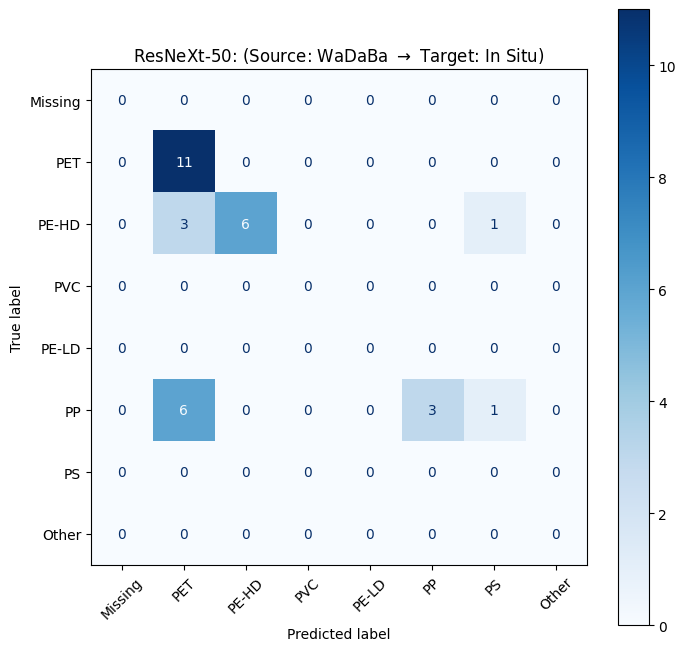

In [18]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def get_confusion_matrix(net, loader, device, num_classes=8):
    net.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels, _ in loader:  # note: IRL loader returns filenames too
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = net(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))
    return cm

# Compute confusion matrix
cm = get_confusion_matrix(model, irl_loader, device)

# Plot
class_names = ['Missing', 'PET', 'PE-HD', 'PVC', 'PE-LD', 'PP', 'PS', 'Other']

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)

plt.title(r"ResNeXt-50: (Source: WaDaBa $\rightarrow$ Target: In Situ)")
plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=300)
plt.show()